In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import os

from GroupMultiNeSS.group_multiness import GroupMultiNeSS, GroupMultiNeSSCV, OracleGroupMultiNeSS
from GroupMultiNeSS.data_generation import LatentPositionGenerator, GroupLatentPositionGenerator
from GroupMultiNeSS.utils import make_group_indices

from typing import Callable
from joblib import cpu_count

##  Data generation

In [3]:
print(f"{cpu_count()} CPUs available")

8 CPUs available


In [11]:
n = 100
M = 16
K = 4
edge_distrib = "normal"
loops_allowed = True
random_state = 1

d = 2
d_shared = d
d_groups=[d] * K
d_individs = [d] * M

group_props = np.ones(K) / K
group_indices = make_group_indices(group_props, M)

In [12]:
lpg = GroupLatentPositionGenerator(n_nodes=n, 
                                   n_layers=M, 
                                   group_indices=group_indices,
                                   edge_distrib=edge_distrib, 
                                   loops_allowed=loops_allowed,
                                   noise_sigma=1,
                                   d_shared=d_shared,
                                   d_individs=d_individs,
                                   d_groups=d_groups)


lpg.generate(random_seed=random_state)
As, Ps, S_true, Qs_true, Rs_true = lpg.As, lpg.Ps, lpg.S, lpg.Qs, lpg.Rs

## GroupMultiNeSS

In [ ]:
init_kwargs = {"max_rank": 10, "loops_allowed": loops_allowed, "edge_distrib": edge_distrib}
fit_kwargs = {"lr": 0.7, "tol": 1e-5, "max_iter": 500, "verbose": False, "verbose_interval": 10}

CPU times: user 36.3 s, sys: 10.3 s, total: 46.6 s
Wall time: 7.25 s
{'Shared component': 0.035, 'Group components': 0.075, 'Individual components': 0.161, 'Ps': 0.103}


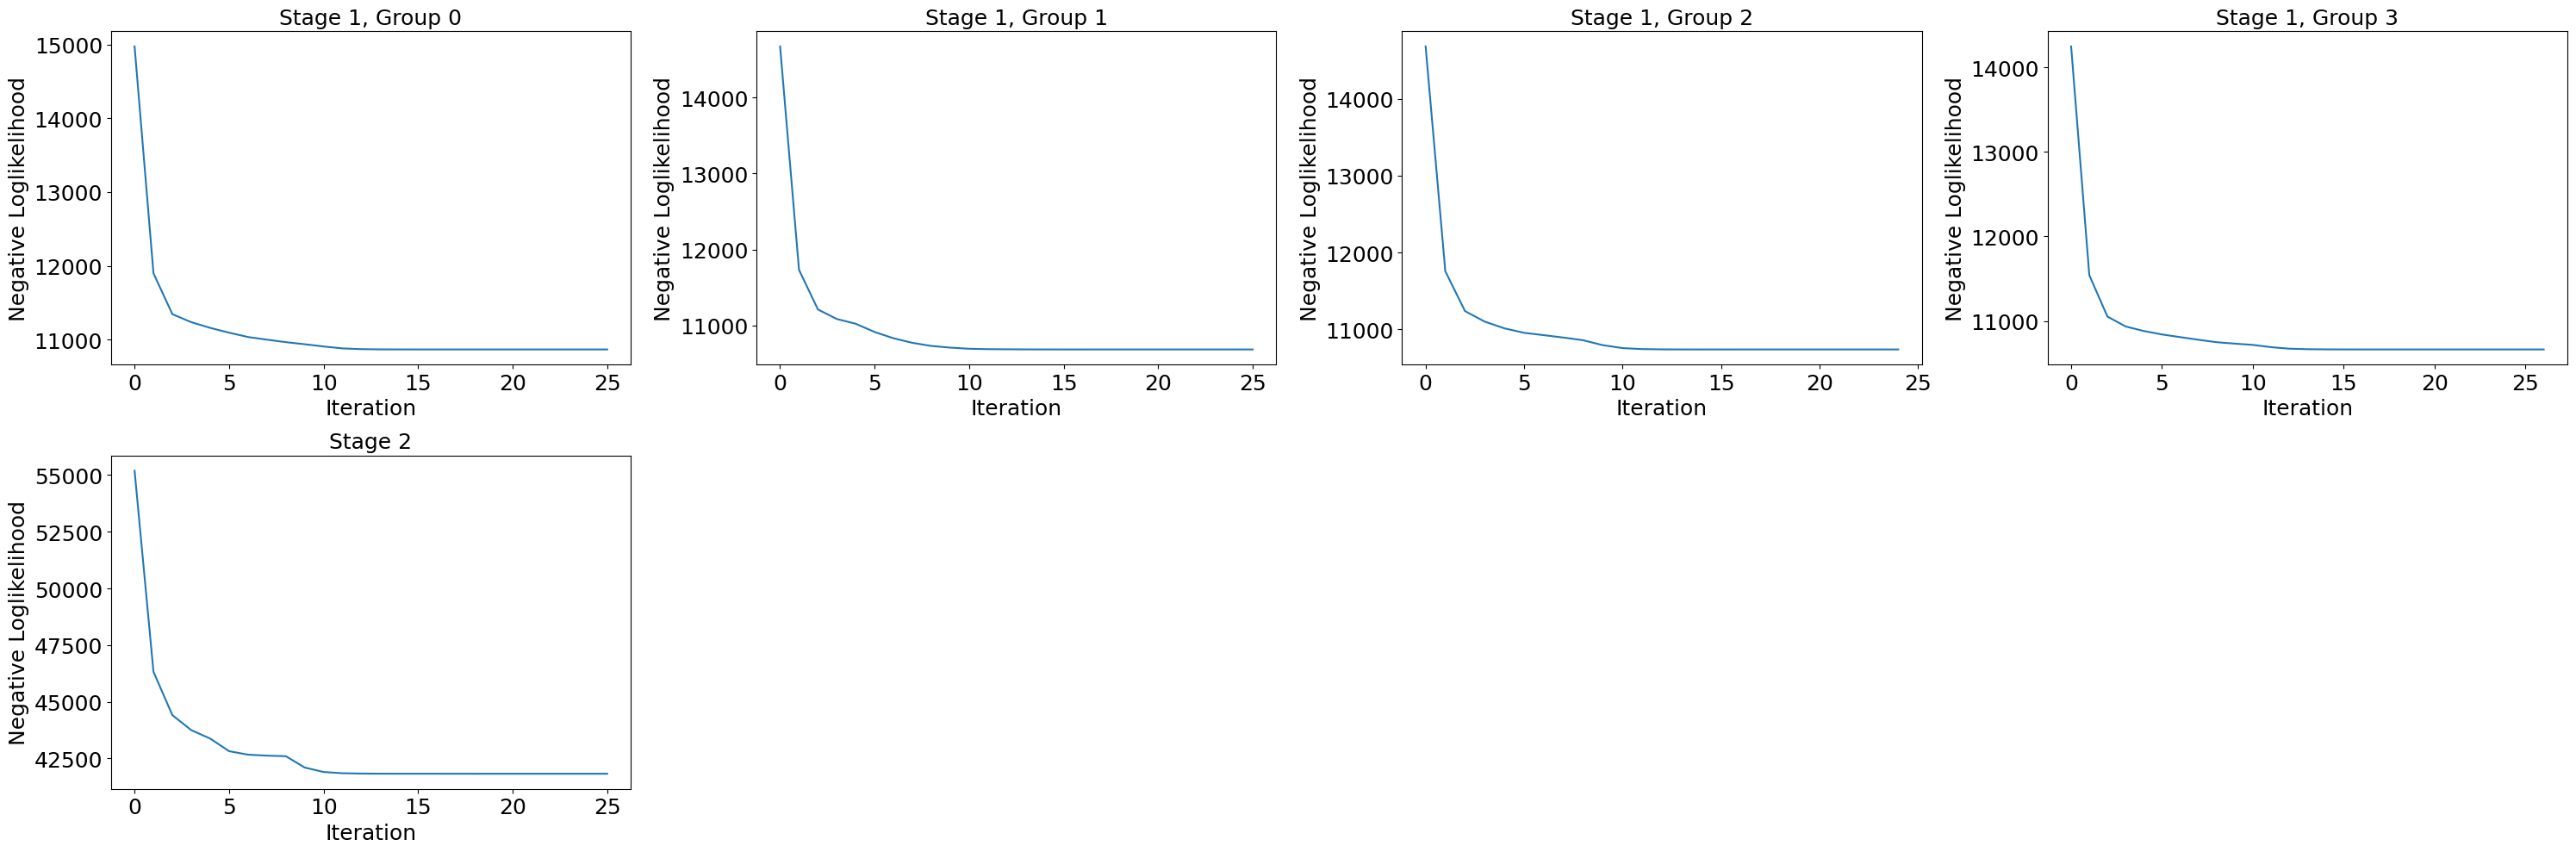

In [14]:
gmn = GroupMultiNeSS(group_indices, **init_kwargs)

%time gmn.fit(As, refit=True, **fit_kwargs)
print(gmn.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps))
gmn.plot_nll_history(figsize=(30, 10), fontsize=18)

## Oracle GroupMultiNeSS (known component ranks)

In [15]:
gmn_oracle = OracleGroupMultiNeSS(group_indices=group_indices,
                                  d_shared=d_shared,
                                  d_individs=d_individs,
                                  d_groups=d_groups)
gmn_oracle.fit(As, **fit_kwargs)

{'Shared component': 0.035, 'Group components': 0.073, 'Individual components': 0.144, 'Ps': 0.095}


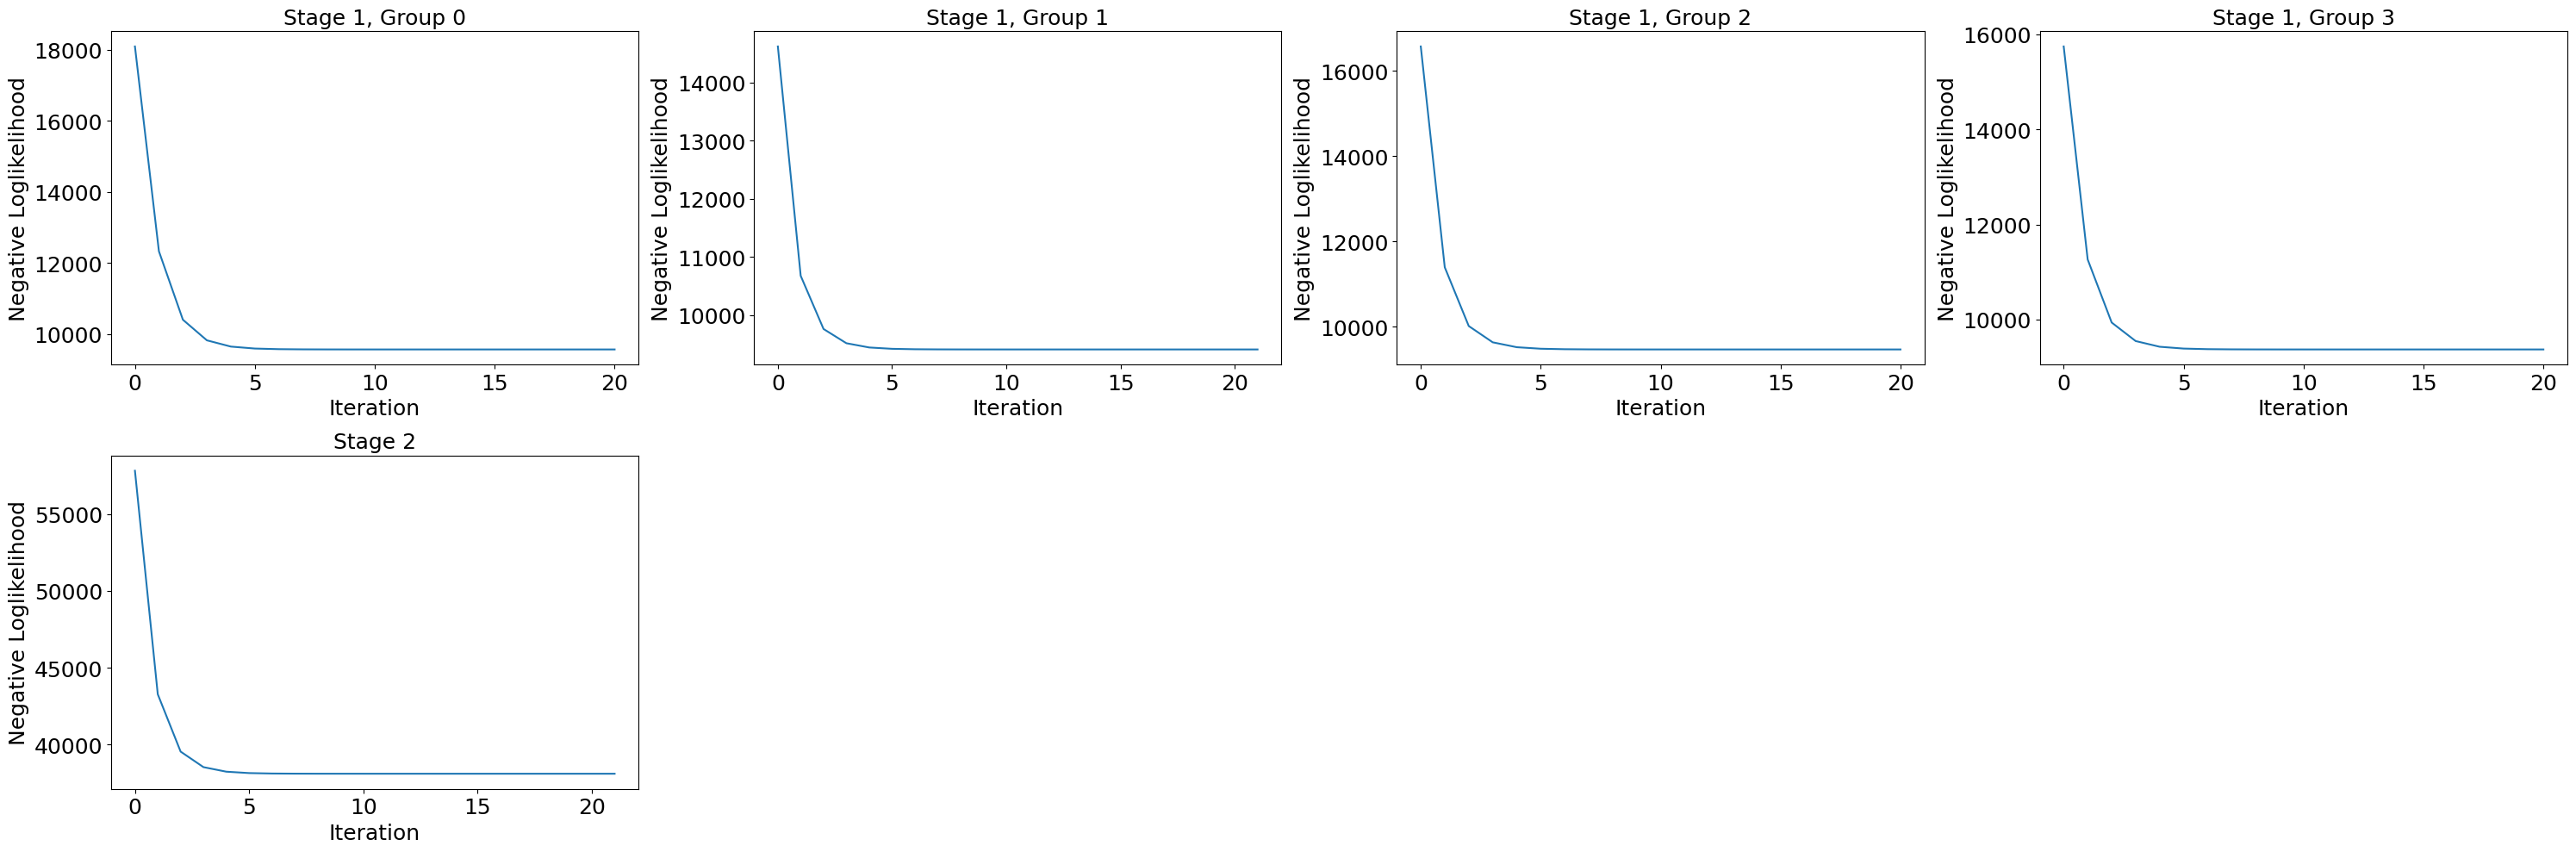

In [16]:
print(gmn_oracle.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps))

gmn_oracle.plot_nll_history(figsize=(30, 10), fontsize=18)

## GroupMultiNeSS with CV

{'Shared component': 0.035, 'Group components': 0.079, 'Individual components': 0.145, 'Ps': 0.097}


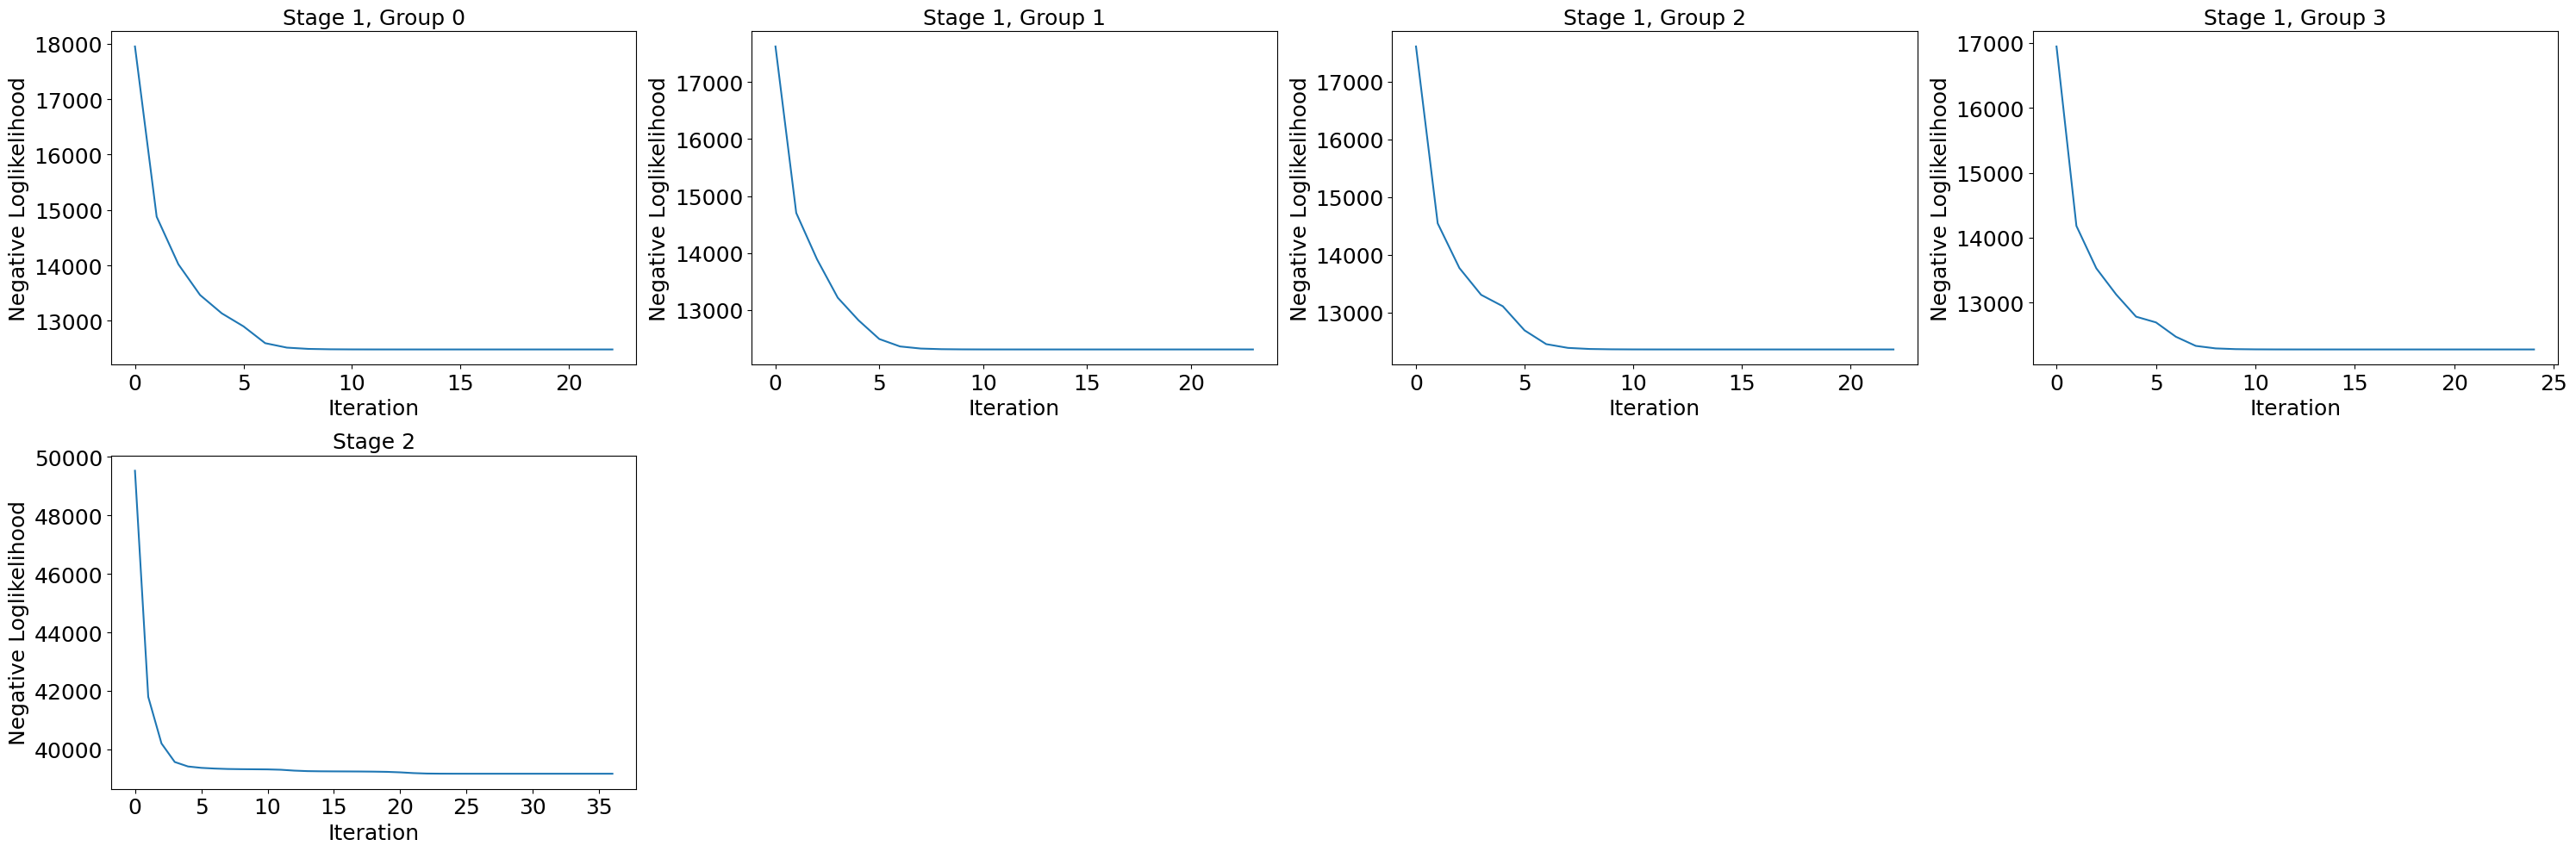

In [18]:
gmn_cv = GroupMultiNeSSCV(group_indices, **init_kwargs)

gmn_cv.fit(As, refit=True, **fit_kwargs)

print(gmn_cv.make_final_error_report(S_true, Qs_true, Rs_true, Ps=Ps))
gmn_cv.plot_nll_history(figsize=(30, 10), fontsize=18)

{(0, 0): {'lmbda1': 60.0}, (0, 1): {'lmbda1': 60.0}, (0, 2): {'lmbda1': 60.0}, (0, 3): {'lmbda1': 60.0}, (1, 0): {'lmbda2': 80.0}}


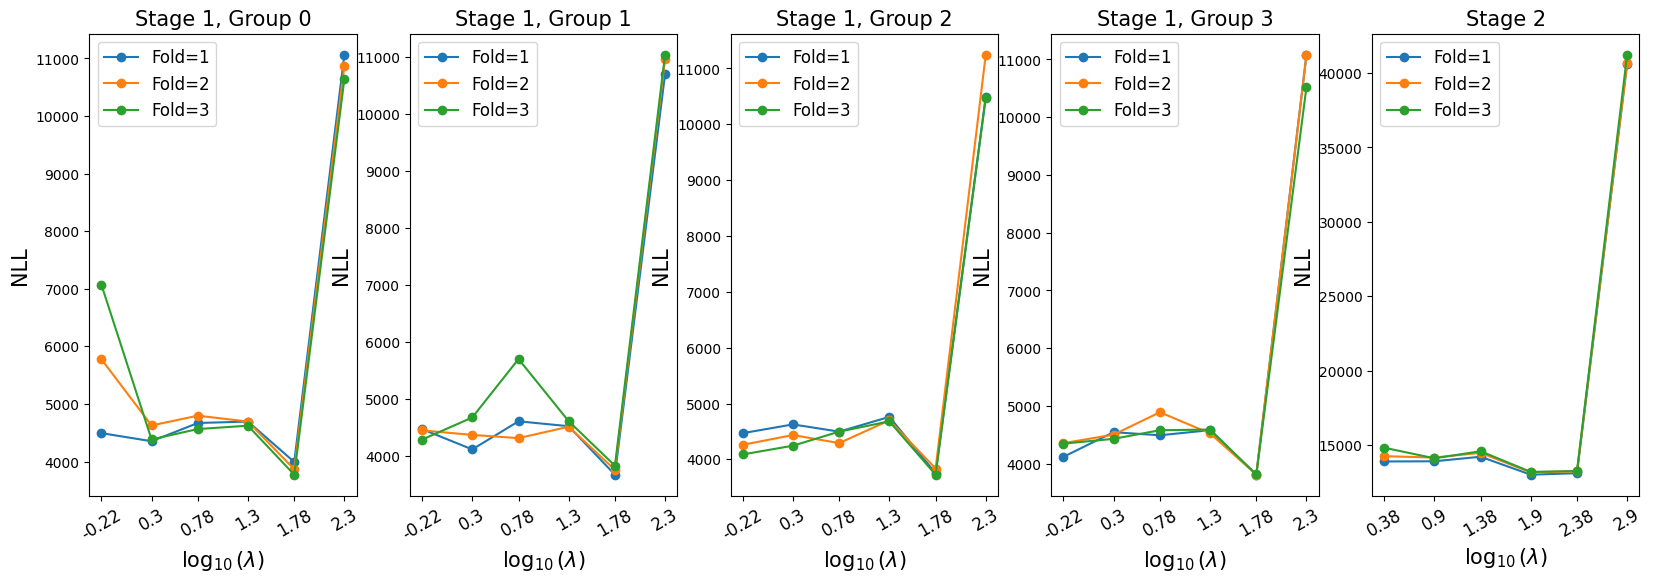

In [20]:
print(gmn_cv.get_best_params_dict())
gmn_cv.plot_cv_results()